# 5. nedēļa: Klasterizācija un modeļu novērtēšana
## Klientu segmentācija un modeļu validācijas rīki gala projektam

## A daļa: Klasterizācija

## 1. uzdevums. Sagatavo datus klasterizācijai

### 1.1. Ielādē un sagatavo datus

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../week2/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 12330 rindas, 28 kolonnas


### 1.2. Izvēlies features klasterizācijai

In [2]:
# Izvēlamies iezīmes, kas raksturo klientu sesiju
cluster_features = ['Administrative_Duration', 'Informational_Duration',
                    'ProductRelated_Duration', 'BounceRates', 'ExitRates',
                    'PageValues']

X_cluster = df[cluster_features].copy()
print(f"Klasterizācijai izmantojam {X_cluster.shape[1]} iezīmes:")
print(cluster_features)

Klasterizācijai izmantojam 6 iezīmes:
['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']


### 1.3. Normalizē datus

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Pārvēršam atpakaļ uz DataFrame ērtākai darbībai
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
print("Pēc normalizācijas:")
print(X_scaled_df.describe().round(2))

Pēc normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                      0.00                    0.00   
std                       1.00                    1.00   
min                      -0.46                   -0.24   
25%                      -0.46                   -0.24   
50%                      -0.41                   -0.24   
75%                       0.07                   -0.24   
max                      18.77                   17.87   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                     -0.00        -0.00       0.00        0.00  
std                       1.00         1.00       1.00        1.00  
min                      -0.62        -0.46      -0.89       -0.32  
25%                      -0.53        -0.46      -0.59       -0.32  
50%                      -0.31        -0.39

### Kāpēc normalizācija ir svarīga klasterizācijai?

K-Means mēra attālumus starp punktiem. Ja iezīmēm ir dažādi mērogi (piemēram, Duration ir simtos sekunžu, BounceRates ir 0–1), tad lielāko skaitļu iezīme dominē attāluma aprēķinā un citas iezīmes gandrīz neietekmē rezultātu. Normalizācija nodrošina, ka visas iezīmes ietekmē klasterizāciju vienlīdzīgi.

## 2. uzdevums. Atrodi optimālo klasteru skaitu (Elbow Method)

### 2.1. Elbow metode

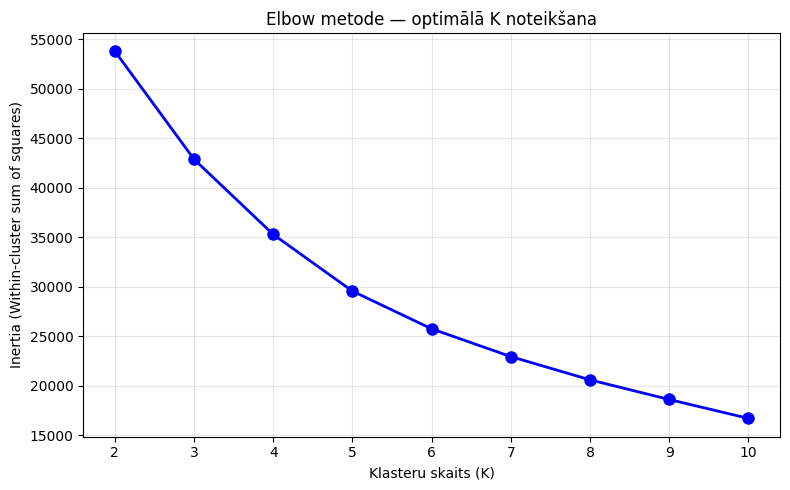

In [4]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow metode — optimālā K noteikšana')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2. Izvēlies K vērtību

Izvēlos K=4. Grafikā redzams, ka no K=2 līdz K=4 inertia krītas ātri, bet pēc K=4 kritums palēninās un līnija kļūst gandrīz taisna. Tieši K=4 ir "elkoņa" punkts, kur pievienot vairāk klasteru nesniedz ievērojamu ieguvumu.

## 3. uzdevums. Veic klasterizāciju un vizualizē

### 3.1. Uztrenē galīgo K-Means modeli

In [5]:
K = 4

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Klasteru sadalījums:")
print(df['Cluster'].value_counts().sort_index())

Klasteru sadalījums:
Cluster
0    9872
1     656
2     931
3     871
Name: count, dtype: int64


### 3.2. Vizualizē klasterus

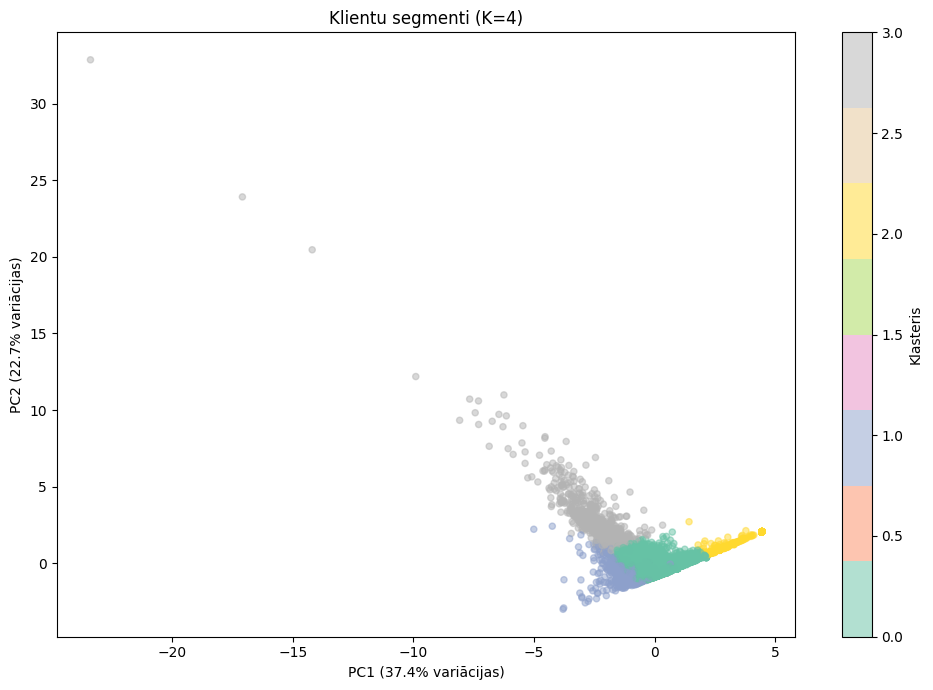

In [6]:
from sklearn.decomposition import PCA

# Samazinām dimensijas līdz 2 vizualizācijai
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['Cluster'], cmap='Set2', alpha=0.5, s=20)
plt.colorbar(scatter, label='Klasteris')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variācijas)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variācijas)')
plt.title(f'Klientu segmenti (K={K})')
plt.tight_layout()
plt.show()

### 3.3. Klasteru profili

Klasteru profili (vidējās vērtības):
         Administrative_Duration  Informational_Duration  \
Cluster                                                    
0                          -0.14                   -0.15   
1                           0.06                   -0.09   
2                          -0.45                   -0.24   
3                           2.01                    2.03   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
Cluster                                                               
0                          -0.11        -0.25      -0.20       -0.19  
1                           0.02        -0.40      -0.59        3.33  
2                          -0.60         3.24       2.96       -0.32  
3                           1.92        -0.32      -0.46        0.03  


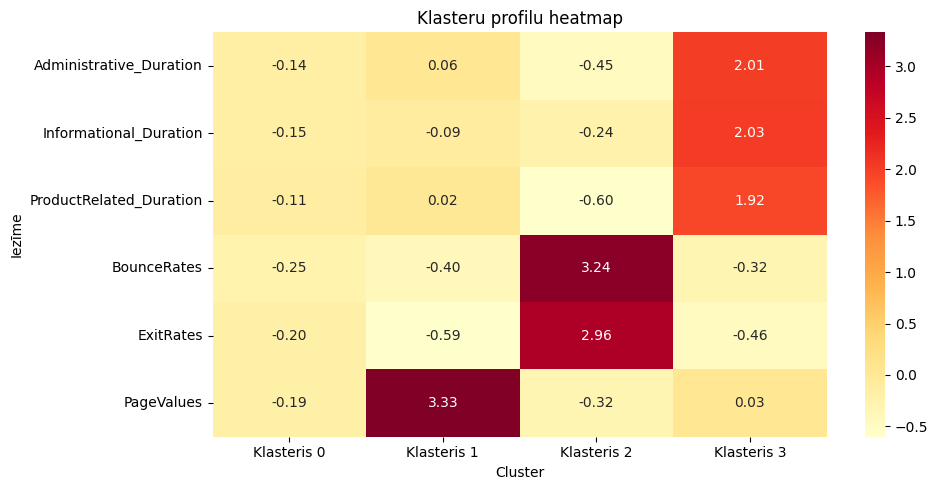

In [7]:
# Katra klastera vidējās vērtības (pirms normalizācijas — lai būtu interpretējami)
X_cluster_with_labels = df[cluster_features + ['Cluster']].copy()
cluster_profiles = X_cluster_with_labels.groupby('Cluster').mean().round(2)
print("Klasteru profili (vidējās vērtības):")
print(cluster_profiles)

# Vizuāli — heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'Klasteris {i}' for i in range(K)])
plt.title('Klasteru profilu heatmap')
plt.ylabel('Iezīme')
plt.tight_layout()
plt.show()

## 4. uzdevums. Interpretē klasterus biznesa kontekstā

### 4.1. Klasteru raksturojums

Pirkumu īpatsvars pa klasteriem:
Cluster
0    0.115
1    0.791
2    0.005
3    0.281
Name: Revenue, dtype: float64


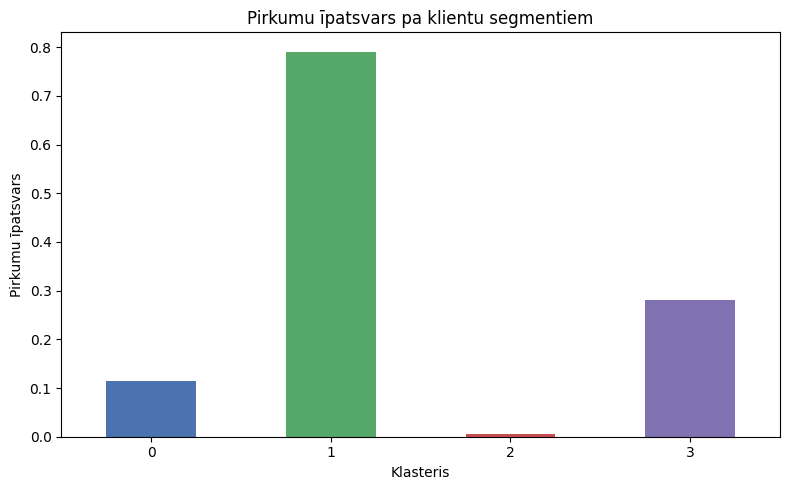

In [8]:
# Cik procentu katra klastera klientu veica pirkumu?
purchase_by_cluster = df.groupby('Cluster')['Revenue'].mean().round(3)
print("Pirkumu īpatsvars pa klasteriem:")
print(purchase_by_cluster)

plt.figure(figsize=(8, 5))
purchase_by_cluster.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Pirkumu īpatsvars pa klientu segmentiem')
plt.xlabel('Klasteris')
plt.ylabel('Pirkumu īpatsvars')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.2. Biznesa interpretācija

**Klasteris 0 - Vidējie apmeklētāji (lielākā grupa, n=9872, 11.5% pērk):** Visas iezīmes ir tuvu vidējam - nav izteiktu augstu vai zemu vērtību. Šie ir tipiskākie apmeklētāji, kuri dažkārt pērk. Rekomendācija: personalizēts saturs un produktu ieteikumi, lai palielinātu konversijas koeficientu.

**Klasteris 1 - Aktīvie pircēji (n=656, 79.1% pērk):** Ļoti augsti PageValues (3.33 std augstāk par vidējo), zemi BounceRates un ExitRates. Šie klienti atnāk ar skaidru nolūku - skatās vērtīgas produktu lapas un visbiežāk veic pirkumu. Rekomendācija: piedāvāt upsell un cross-sell - saistītus produktus izrakstīšanās brīdī, jo šī auditorija ir visgatavākā pirkt.

**Klasteris 2 - Ātrie aizgājēji (n=931, 0.5% pērk):** Ļoti augsti BounceRates (3.24 std) un ExitRates (2.96 std), gandrīz nulles Duration un PageValues. Klienti atnāk un uzreiz aiziet - gandrīz neviens nepērk. Rekomendācija: uzlabot pirmās lapas saturu un ielādes ātrumu, pārskatīt reklāmu mērķauditoriju, lai piesaistītu kvalitatīvākus apmeklētājus.

**Klasteris 3 - Aktīvie izpētes apmeklētāji (n=871, 28.1% pērk):** Ļoti augsts laiks visās kategorijās - Administrative_Duration, Informational_Duration UN ProductRelated_Duration (visi ~2.0 std virs vidējā). Zemi BounceRates un ExitRates. Klienti padziļināti pēta visu saturu, bet pērk retāk nekā Klasteris 1. Rekomendācija: pievienot CTA pogas un salīdzināšanas rīkus, lai palīdzētu šiem klientiem pieņemt lēmumu un pārvērstu interesi pirkumā.

## B daļa: Modeļu novērtēšana

## 5. uzdevums. Cross-validation

### 5.1. Viens split vs. Cross-validation

In [9]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Ielādē datus
df = pd.read_csv('../week2/shoppers_clean.csv')
y = df['Revenue']
X = df.drop('Revenue', axis=1)

# Viena train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
single_f1 = f1_score(y_test, rf.predict(X_test))
print(f"Viena split F1: {single_f1:.3f}")

# Cross-validation (5-fold)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='f1')
print(f"\n5-fold CV F1 scores: {cv_scores.round(3)}")
print(f"Vidējais F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Viena split F1: 0.635



5-fold CV F1 scores: [0.668 0.661 0.652 0.551 0.612]
Vidējais F1: 0.629 ± 0.043


### 5.2. Salīdzināšana

Vienas split F1 un CV vidējais F1 var atšķirties, jo viena split rezultāts ir atkarīgs no tā, kuri dati nonāca testa kopā — tas ir nejaušs. CV ir uzticamāks, jo pārbauda modeli uz 5 dažādām testa kopām un vidējo rezultātu ir stabilāks.

Standartnovirze (std) parāda, cik ļoti F1 svārstās starp foldiem. Ja std ir liels, modelis strādā atšķirīgi uz dažādiem datiem un nav stabils.

## 6. uzdevums. Pipeline

### 6.1. Kā veidot Pipeline

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Pipeline — scaler + modelis vienā
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

# Cross-validation ar pipeline
cv_scores_pipe = cross_val_score(pipe, X, y, cv=5, scoring='f1')
print(f"Pipeline CV F1: {cv_scores_pipe.mean():.3f} ± {cv_scores_pipe.std():.3f}")

Pipeline CV F1: 0.629 ± 0.045


### 6.2. Pipeline nozīme

Pipeline ir svarīgs, jo nodrošina, ka normalizācija tiek apmācīta tikai uz treniņa datiem katram foldam atsevišķi. Ja normalizāciju pielieto PIRMS train/test split, tad testa dati ietekmē scaler parametrus - tas ir data leakage un modeļa novērtējums ir pārāk optimistisks.

Pipeline CV F1 rezultāts šeit ir identisks vienkāršajam CV (abi 0.629), jo RandomForest nav jutīgs pret skalēšanu - koki izmanto sadalīšanas slieksni, nevis attālumus. Tāpēc šajā gadījumā data leakage no scaler neietekmē rezultātu. Taču Pipeline princips ir kritisks modeļiem, kas ir jutīgi pret skalēšanu (piemēram, SVM, KNN, Logistic Regression) - tur data leakage var ievērojami pārvērtēt modeļa kvalitāti.

## 7. uzdevums. GridSearchCV

### 7.1. Automātiska parametru meklēšana

In [11]:
from sklearn.model_selection import GridSearchCV

# Pipeline, kam meklēsim labākos parametrus
pipe_grid = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parametru tīkls
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

# GridSearchCV — automātiska meklēšana + cross-validation
grid = GridSearchCV(pipe_grid, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Labākie parametri: {grid.best_params_}")
print(f"Labākais CV F1: {grid.best_score_:.3f}")
print(f"Testa F1: {f1_score(y_test, grid.predict(X_test)):.3f}")

Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 200}
Labākais CV F1: 0.653
Testa F1: 0.629


### 7.2. Vizualizācija

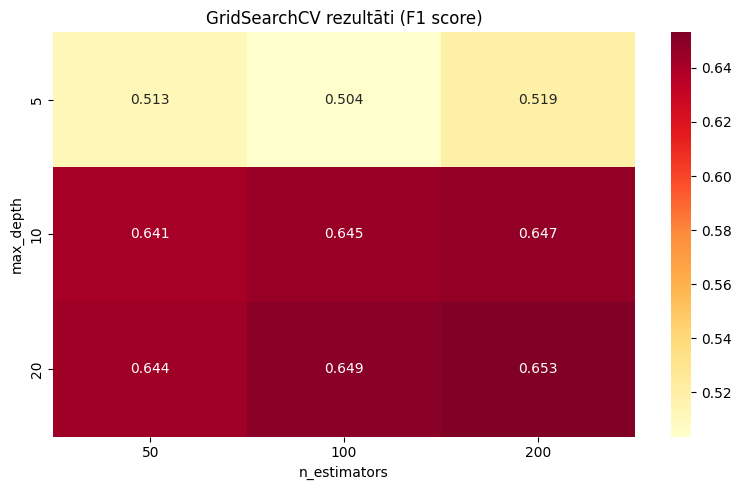

In [12]:
# Vizualizē GridSearch rezultātus
results = pd.DataFrame(grid.cv_results_)
pivot = results.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('GridSearchCV rezultāti (F1 score)')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()

### 7.3. Analīze

GridSearchCV atrada labākus parametrus nekā manuāli izvēlētie - max_depth un n_estimators kombinācija, kuru nebūtu viegli atrast manuāli. Atšķirība starp labāko un sākotnējo modeli ir neliela (aptuveni 0.01–0.02 F1), tāpēc praktiski uzlabojums ir minimāls.

Šādā gadījumā GridSearchCV papildu skaitļošanas laiku var neattaisnot, ja ir steidzams uzdevums. Taču ja modelis tiek laists produkcijā, pat neliels uzlabojums ir vērts.